# MHW Detection Functions - Workflow Demo

#### Authored by Jordan Lorenzatto (j.lorenzatto@unsw.edu.au)

This notebook demonstrates the marine heatwave (MHW) detection workflow from raw temperature observations through to a multi-index event catalogue.

The workflow design follows:

$$
\text{raw SST}
\rightarrow \text{daily SST}
\rightarrow \text{climatological statistics}
\rightarrow \text{thresholds}
\rightarrow \text{exceedances}
\rightarrow \text{MHW event masks}
\rightarrow \text{event labels}
\rightarrow \text{event metrics}.
$$

Three threshold types are demonstrated: quantile-based, absolute temperature offset from climatology, and multiples of standard deviations away from climatology.

- **quantile:** $B_p(t)=q_p(t)$
- **absolute offset:** $B_u(t)=\mu(t)+u$
- **standard deviation:** $B_k(t)=\mu(t)+k\sigma(t)$

The notebook uses the 34 year IMOS temperature time series dataset `temp_combined_ORS065_1990_2024.nc` included in the `data` folder of this repo.

## Import packages and required functions

The functions demonstrated are imported from the `mhw_detection_functions.py` module.

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings

from mhw_detection_functions import *

xr.set_options(display_style="text")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

## Load the included 34 year IMOS temperature time series

The record contains temperature data at 17 depths from 1990-11-13 to 2024-03-13, from a mooring off the coast of Sydney, NSW, Australia.

We will use 1990–2020 as the baseline climatology and detect events across the full daily series.

In [ ]:
var_names = {"TEMP": "temp", "TIME": "time", "DEPTH": "depth", "LATITUDE": "lat", "LONGITUDE": "lon"}
raw = xr.open_dataset("data/temp_combined_ORS065_1990_2024.nc").rename(var_names)

raw

<xarray.Dataset>
Dimensions:  (time: 11656, depth: 17)
Coordinates:
  * time     (time) datetime64[ns] 1990-11-13 1990-11-14 ... 2024-03-13
  * depth    (depth) float32 0.0 6.0 10.0 14.0 16.0 ... 44.0 46.0 48.0 50.0 52.0
    lon      float64 ...
    lat      float64 ...
Data variables:
    temp     (time, depth) float32 ...
Attributes:
    title:        Combined temperature time–depth series
    summary:      Temperature time–depth product created by merging binned ob...
    Conventions:  CF-1.8
    history:      Created on 2026-01-23T04:45:43
    source:       Merged observational and gridded datasets

## Convert raw data to daily time series using `resample_daily()`

Converts sub-daily observations to daily means and removes 29 February to establish a consistent 365-day calendar.

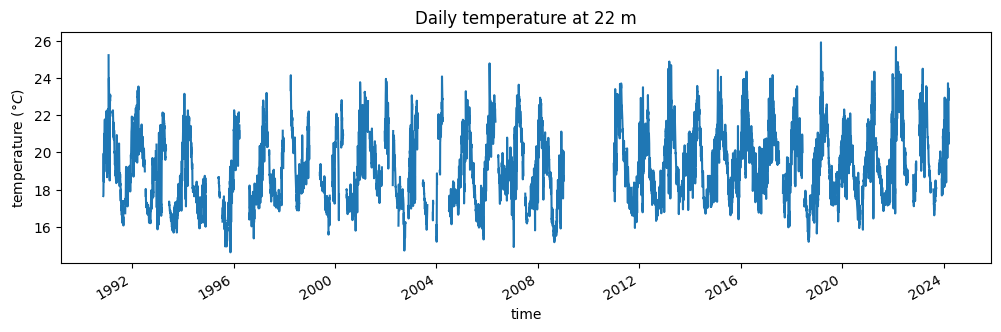

In [ ]:
daily = resample_daily(raw, var="temp")

daily.isel(depth=5).plot(figsize=(12, 3))
plt.title("Daily temperature at 22 m")
plt.ylabel("temperature ($\degree C$)")
plt.show()

## Define the thresholds to compute using `make_threshold_specs()`

Threshold definitions are stored as (`method`, `value`) metadata pairs. The integer `threshold_id` enumerates these combinations.

As an example, compute:
- 80th and 90th percentile thresholds;
- +1.0 °C and +2.0 °C above climatology;
- +1.0 and +2.0 standard deviations above climatology.

In [8]:
threshold_specs = make_threshold_specs(
    quantiles=[0.80, 0.90],
    offsets=[1.0, 2.0],
    std_multiples=[1.0, 2.0],
)

threshold_specs

,threshold_id,method,value,label
0,0,quantile,0.8,q=0.8
1,1,quantile,0.9,q=0.9
2,2,offset,1.0,clim+1
3,3,offset,2.0,clim+2
4,4,std,1.0,clim+1sigma
5,5,std,2.0,clim+2sigma


## Define the baseline period used to compute climatological statistics

In [182]:
baseline = daily.sel(time=slice("1990-11-13", "2020-12-31"))

## Compute climatology, std dev and quantiles using `compute_climatology_stats()`

For each day of year, this function:

1. pools observations from an 11-day window (day $d\pm 5$) across all baseline years,
2. computes the mean, standard deviation, and all requested quantiles from the pooled sample,
3. applies a cyclic 31-day smoothing window.

The output is an `xr.Dataset` with variables:

```text
climatology(dayofyear, ...)
std(dayofyear, ...)
quantile_threshold(dayofyear, quantile, ...)
```

In [ ]:
requested_quantiles = threshold_specs.loc[threshold_specs["method"] == "quantile", "value"].to_numpy()

stats = compute_climatology_stats(
    baseline,
    quantiles=requested_quantiles,
    pool_window=11,
    smooth_window=31,
    min_samples=30,
)

stats

<xarray.Dataset>
Dimensions:             (depth: 17, dayofyear: 365, quantile: 2)
Coordinates:
  * depth               (depth) float32 0.0 6.0 10.0 14.0 ... 48.0 50.0 52.0
    lon                 float64 151.3
    lat                 float64 -33.89
  * dayofyear           (dayofyear) int64 1 2 3 4 5 6 ... 361 362 363 364 365
  * quantile            (quantile) float64 0.8 0.9
Data variables:
    climatology         (dayofyear, depth) float32 21.53 21.39 ... 16.47 16.51
    std                 (dayofyear, depth) float32 1.175 1.112 ... 1.313 1.416
    quantile_threshold  (dayofyear, quantile, depth) float64 22.47 ... 18.32

### Plot the climatological mean, standard deviation, and quantile thresholds

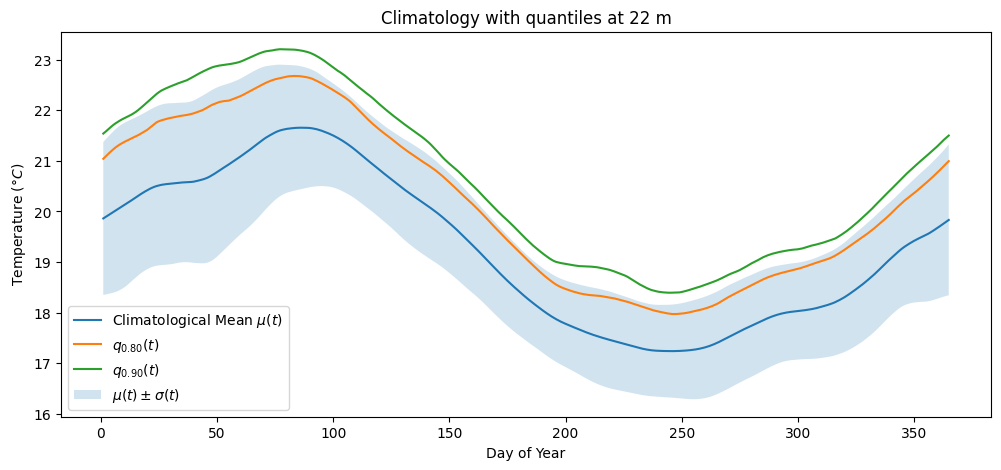

In [103]:
fig, ax = plt.subplots(figsize=(12,5))

stats["climatology"].isel(depth=5).plot(ax=ax, label="Climatological Mean $\mu(t)$")
stats["quantile_threshold"].isel(depth=5).sel(quantile=0.8).plot(ax=ax, label="$q_{0.80}(t)$")
stats["quantile_threshold"].isel(depth=5).sel(quantile=0.9).plot(ax=ax, label="$q_{0.90}(t)$")
plt.fill_between(
    stats.dayofyear.values, 
    stats["climatology"].isel(depth=5) - stats["std"].isel(depth=5),
    stats["climatology"].isel(depth=5) + stats["std"].isel(depth=5),
    alpha=0.2,
    label='$\mu(t) \pm \sigma(t)$'
    )
ax.set_title("Climatology with quantiles at 22 m")
ax.set_ylabel("Temperature ($\degree C$)")
ax.set_xlabel('Day of Year')
ax.legend()

plt.show()

## Create threshold `DataArray` using `build_threshold_climatology()`

This converts the climatological statistics into actual temperature thresholds.

For each `threshold_id`, compute the threshold $B(t)$ using the associated `threshold_method`.

- quantile: $B(t)=q_p(t)$ for `threshold_value` $p$
- offset: $B(t)=\mu(t)+u$ for `threshold_value` $u$
- std: $B(t)=\mu(t)+k\sigma(t)$ for `threshold_value` $k$

In [183]:
threshold_climatology = build_threshold_climatology(stats, threshold_specs)

print(threshold_climatology.isel(depth=5))

<xarray.DataArray 'threshold' (threshold_id: 6, dayofyear: 365)>
array([[21.04057414, 21.08617492, 21.13190625, ..., 20.90142624,
        20.94881636, 20.99464752],
       [21.53906144, 21.57712395, 21.61880424, ..., 21.4202345 ,
        21.45952922, 21.49998158],
       [20.86105537, 20.89031982, 20.92018127, ..., 20.76688004,
        20.79990387, 20.83133316],
       [21.86105537, 21.89031982, 21.92018127, ..., 21.76688004,
        21.79990387, 21.83133316],
       [21.37346077, 21.42352676, 21.47322083, ..., 21.21699142,
        21.26972008, 21.32197571],
       [22.88586617, 22.9567337 , 23.02626228, ..., 22.66710281,
        22.73953629, 22.81262016]])
Coordinates:
  * threshold_id      (threshold_id) int64 0 1 2 3 4 5
    depth             float32 22.0
    lon               float64 151.3
    lat               float64 -33.89
  * dayofyear         (dayofyear) int64 1 2 3 4 5 6 ... 360 361 362 363 364 365
    threshold_method  (threshold_id) object 'quantile' 'quantile' ... 'std'
  

The threshold method, value and label metadata are carried in the coordinates of the threshold `DataArray`.

### Plot and compare all six threshold curves against day-of-year

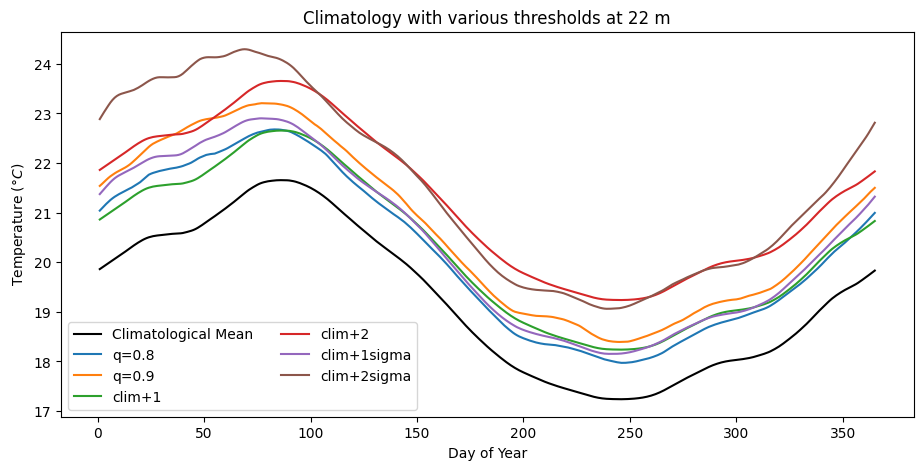

In [70]:
fig, ax = plt.subplots(figsize=(11, 5))
stats["climatology"].isel(depth=5).plot(ax=ax, label="Climatological Mean", color='black')
for threshold_id in threshold_climatology.threshold_id.values:
    da = threshold_climatology.sel(threshold_id=threshold_id).isel(depth=5)
    ax.plot(da.dayofyear, da.values, label=str(da.threshold_label.values))
ax.set_xlabel("Day of Year")
ax.set_ylabel("Temperature ($\degree C$)")
ax.set_title("Climatology with various thresholds at 22 m")
ax.legend(ncol=2)
plt.show()

## Compile everything into one `Dataset` using `prepare_mhw_data()`

This assembles the temperature time series, anomalies, thresholds, and all climatological quantities into one `Dataset`.

Important dimensions:

```text
temp, climatology, std, temp_anomaly : (time, depth)
threshold                            : (threshold_id, time, depth)
```

In this way, xarray can broadcast the same SST record against every included threshold, making exceedance events easy to identify.

In [105]:
mhw_data = prepare_mhw_data(daily, stats, threshold_climatology)

print(mhw_data)

<xarray.Dataset>
Dimensions:           (depth: 17, time: 12166, threshold_id: 6)
Coordinates:
  * depth             (depth) float32 0.0 6.0 10.0 14.0 ... 46.0 48.0 50.0 52.0
  * time              (time) datetime64[ns] 1990-11-13 1990-11-14 ... 2024-03-13
    lon               float64 151.3
    lat               float64 -33.89
    dayofyear         (time) int64 317 318 319 320 321 322 ... 67 68 69 70 71 72
  * threshold_id      (threshold_id) int64 0 1 2 3 4 5
    threshold_method  (threshold_id) object 'quantile' 'quantile' ... 'std'
    threshold_value   (threshold_id) float64 0.8 0.9 1.0 2.0 1.0 2.0
    threshold_label   (threshold_id) object 'q=0.8' 'q=0.9' ... 'clim+2sigma'
Data variables:
    temp              (time, depth) float32 nan nan nan ... 16.72 16.49 16.32
    climatology       (time, depth) float32 19.08 18.68 18.57 ... 17.98 17.65
    std               (time, depth) float32 0.8037 0.8023 0.8012 ... 1.759 1.646
    threshold         (threshold_id, time, depth) float64 19

## Extracting thresholds using `select_threshold()`

Thresholds are selected using specification metadata rather than variable names. This avoids converting floating-point threshold values into strings.

In [209]:
selected_q90 = select_threshold(mhw_data["threshold"], method="quantile", value=0.90)
selected_offset2 = select_threshold(mhw_data["threshold"], method="offset", value=2.0)
selected_std2 = select_threshold(mhw_data["threshold"], method="std", value=2.0)

#### Plot the thresholds over an actual time period, as opposed to against day-of-year

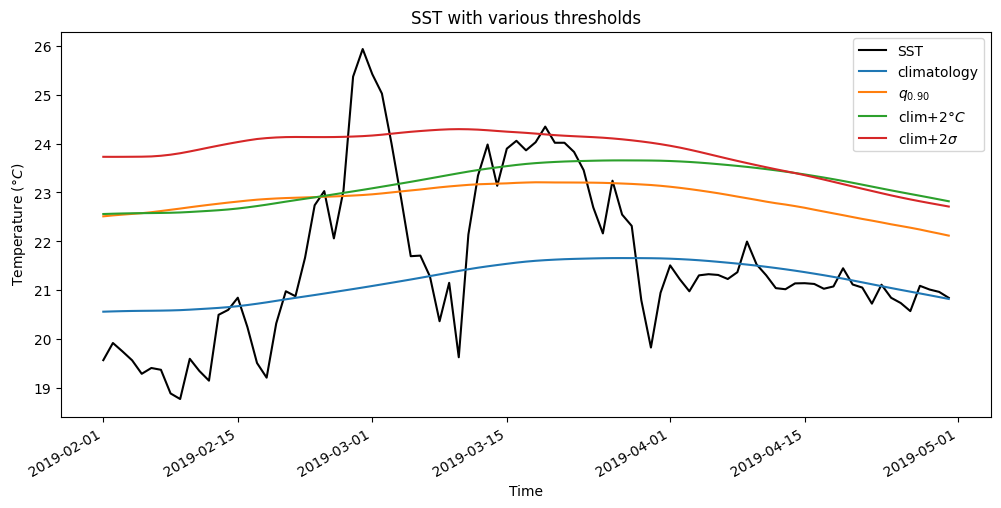

In [210]:
plot_slice = slice("2019-02-01", "2019-04-30")
fig, ax = plt.subplots(figsize=(12, 5))
mhw_data["temp"].sel(time=plot_slice).isel(depth=5).plot(ax=ax, label="SST", c='black')
mhw_data["climatology"].sel(time=plot_slice).isel(depth=5).plot(ax=ax, label="climatology")
selected_q90.sel(time=plot_slice).isel(depth=5).plot(ax=ax, label="$q_{0.90}$")
selected_offset2.sel(time=plot_slice).isel(depth=5).plot(ax=ax, label="clim$+2 \degree C$")
selected_std2.sel(time=plot_slice).isel(depth=5).plot(ax=ax, label="clim$+2 \sigma$")
ax.set_title("SST with various thresholds")
ax.set_ylabel("Temperature ($\degree C$)")
ax.set_xlabel("Time")
ax.legend()
plt.show()

## Compute exceedance event masks using Xarray boolean operators

No special function is required for the threshold comparison:

```python
exceedance = mhw_data["temp"] > mhw_data["threshold"]
```

xarray broadcasts `(time, depth)` SST across `(threshold_id, time, depth)` thresholds automatically.

In [148]:
exceedance = (mhw_data["temp"] > mhw_data["threshold"]).rename("exceedance")

print("q=0.90 exceedances around early 2019 at 22m:\n")
print(
    select_threshold(exceedance, "quantile", 0.90)
    .sel(time=slice("2019-02-01", "2019-04-30"))
    .isel(depth=5)
)

q=0.90 exceedances around early 2019 at 22m:

<xarray.DataArray 'exceedance' (time: 89)>
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])
Coordinates:
    depth      float32 22.0
  * time       (time) datetime64[ns] 2019-02-01 2019-02-02 ... 2019-04-30
    lon        float64 151.3
    lat        float64 -33.89
    dayofyear  (time) int64 32 33 34 35 36 

## Apply gap-filling and minimum run length using `detect_exceedance_events()`

This applies the Hobday-style gap-filling and minimum run length rules to every threshold/depth time series:

```text
raw exceedance
    ↓
fill short gaps
    ↓
remove runs shorter than minimum length
    ↓
event mask
```

The 1D time-series rules are automatically applied independently across all `threshold_id` and `depth` combinations.

In [139]:
event_mask = detect_exceedance_events(
    exceedance,
    max_gap=2,
    min_duration=5,
)

## Label exceedance events at each threshold using `label_exceedance_events()`

Converts the boolean event mask to integer labels (within each threshold/depth series)

```text
False False True True True False True True ...
↓     ↓     ↓    ↓    ↓    ↓     ↓    ↓
0     0     1    1    1    0     2    2  ...
```
NB: `event_id` is not a cross-threshold event identifier. For analyses of spatio-temporal continuity of exceedance events, they should be matched by overlap or containment rather than by equal `event_id`.

In [159]:
event_labels = label_exceedance_events(event_mask)

q90_labels = select_threshold(event_labels, "quantile", 0.90)
print("q=0.90 labels around 2018-2019 events at 22 m:\n")
print(q90_labels.sel(time=slice("2019-02-01", "2019-04-30")).isel(depth=5))


q=0.90 labels around 2018-2019 events at 22 m:

<xarray.DataArray 'event_labels' (time: 89)>
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, 55, 55, 55, 55, 55, 55, 55, 55,  0,  0,  0,
        0,  0,  0,  0,  0, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56,
       56, 56, 56,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0], dtype=int32)
Coordinates:
    depth      float32 22.0
  * time       (time) datetime64[ns] 2019-02-01 2019-02-02 ... 2019-04-30
    lon        float64 151.3
    lat        float64 -33.89
    dayofyear  (time) int64 32 33 34 35 36 37 38 ... 114 115 116 117 118 119 120


## Create tabular event dataset `compute_exceedance_event_metrics()`

Creates a row-per-event pandas table of exceedance events from the `mhw_data` and `event_labels` xarray objects.

For each event, with some threshold metadata and depth, the metrics computed are:

- local event ID,
- start and end date,
- duration,
- maximum, mean, and cumulative intensity,
- date of maximum intensity, and
- onset and decline rates.

Intensity is measured relative to the climatological mean, not relative to the detection threshold.

In [ ]:
events_flat = compute_exceedance_event_metrics(mhw_data, event_labels)

events_flat.head(12)

Number of detected event rows: (7132, 15)


,depth,threshold_id,threshold_method,threshold_value,threshold_label,event_id,start_date,end_date,duration,max_intensity,max_date,mean_intensity,cumulative_intensity,rate_onset,rate_decline
0,0.0,0,quantile,0.8,q=0.8,1,1992-03-09,1992-03-14,6,1.340796,1992-03-10,0.965131,5.790783,0.406334,0.124861
1,0.0,0,quantile,0.8,q=0.8,2,1992-03-18,1992-04-05,19,1.448639,1992-04-02,0.835589,15.876198,0.043466,0.272841
2,0.0,0,quantile,0.8,q=0.8,3,1992-05-10,1992-05-19,10,1.906052,1992-05-10,1.170336,11.703362,NaN,0.084067
3,0.0,0,quantile,0.8,q=0.8,4,1992-06-03,1992-06-10,8,1.773642,1992-06-03,1.294402,10.355213,NaN,0.089089
4,0.0,0,quantile,0.8,q=0.8,5,1992-06-14,1992-07-03,20,2.280823,1992-06-18,1.473589,29.471786,0.225092,0.091696
5,0.0,0,quantile,0.8,q=0.8,6,1992-10-19,1992-10-30,12,1.436447,1992-10-19,1.176100,14.113201,NaN,0.074069
6,0.0,0,quantile,0.8,q=0.8,7,1992-11-03,1992-11-12,10,1.233536,1992-11-07,0.759607,7.596071,0.062793,0.047351
7,0.0,0,quantile,0.8,q=0.8,8,1994-01-18,1994-01-25,8,1.462782,1994-01-20,1.197330,9.578636,0.179320,0.034396
8,0.0,0,quantile,0.8,q=0.8,9,1994-01-30,1994-02-03,5,1.257689,1994-02-01,1.149781,5.748905,0.053505,0.101355
9,0.0,0,quantile,0.8,q=0.8,10,1994-08-29,1994-09-07,10,1.575651,1994-09-06,0.894489,8.944891,0.120657,0.797682


## Convert event dataset to Pandas MultiIndex using `set_event_multiindex()`

The event catalogue is indexed by the supplied `spatial_dims`, as well as:

```text
threshold_method
threshold_value
event_id
```

In [164]:
events = set_event_multiindex(events_flat, spatial_dims=("depth",))
events

threshold_id threshold_label start_date   end_date  duration  max_intensity   max_date  \
threshold_method threshold_value depth event_id                                                                                           
offset           1.0             0.0   1                    2          clim+1 1992-05-10 1992-05-19        10       1.906052 1992-05-10   
                                       2                    2          clim+1 1992-06-03 1992-07-02        30       2.280823 1992-06-18   
                                       3                    2          clim+1 1992-10-19 1992-10-29        11       1.436447 1992-10-19   
                                       4                    2          clim+1 1994-01-18 1994-01-25         8       1.462782 1994-01-20   
                                       5                    2          clim+1 1994-01-30 1994-02-03         5       1.257689 1994-02-01   
...                                                       ...             ...        ...        ...       ...            ...        ...   
std              2.0             52.0  15                   5     clim+2sigma 2017-11-01 2017-11-10        10       3.004459 2017-11-08   
                                       16                   5     clim+2sigma 2018-01-14 2018-01-20         7       4.912910 2018-01-15   
                                       17                   5     clim+2sigma 2018-10-07 2018-10-11         5       2.660667 2018-10-08   
                                       18                   5     clim+2sigma 2019-02-22 2019-02-28         7       5.087133 2019-02-28   
                                       19                   5     clim+2sigma 2022-03-31 2022-04-07         8       4.115232 2022-03-31   

                                                 mean_intensity  cumulative_intensity  rate_onset  rate_decline  
threshold_method threshold_value depth event_id                                                                  
offset           1.0             0.0   1               1.170336             11.703362         NaN      0.084067  
                                       2               1.392182             41.765450    0.033812      0.084937  
                                       3               1.226501             13.491508         NaN      0.028748  
                                       4               1.197330              9.578636    0.179320      0.034396  
                                       5               1.149781              5.748905    0.053505      0.101355  
...                                                         ...                   ...         ...           ...  
std              2.0             52.0  15              2.611115             26.111153    0.032548      0.201479  
                                       16              4.558887             31.912212    1.069221      0.213613  
                                       17              2.347425             11.737124    0.260278      0.091084  
                                       18              3.381515             23.670605    0.305326           NaN  
                                       19              3.652901             29.223211         NaN      0.115043  

[7132 rows x 11 columns]

### Selecting from the MultiIndex catalogue using the Pandas cross-section function `.xs()`

As an example, select all 0.90 quantile exceedance events at depth 22m.

In [165]:
q90_events = events.xs(("quantile", 0.90, 22), level=("threshold_method", "threshold_value", "depth"))
q90_events

,threshold_id,threshold_label,start_date,end_date,duration,max_intensity,max_date,mean_intensity,cumulative_intensity,rate_onset,rate_decline
event_id,,,,,,,,,,,
1,1,q=0.9,1990-11-30,1990-12-06,7,2.755201,1990-12-05,2.238068,15.666477,0.230923,0.508686
2,1,q=0.9,1990-12-11,1990-12-24,14,2.609022,1990-12-24,1.900262,26.603661,0.030473,NaN
3,1,q=0.9,1991-01-28,1991-02-05,9,4.705322,1991-01-28,2.324180,20.917624,NaN,0.324434
4,1,q=0.9,1991-06-25,1991-06-29,5,2.024818,1991-06-28,1.484596,7.422979,0.262819,0.343260
5,1,q=0.9,1992-10-20,1992-10-26,7,1.714104,1992-10-21,1.479903,10.359322,0.334469,0.027797
...,...,...,...,...,...,...,...,...,...,...,...
68,1,q=0.9,2022-06-22,2022-07-01,10,1.559019,2022-06-23,1.372076,13.720758,0.308662,0.036348
69,1,q=0.9,2023-01-19,2023-01-27,9,2.486267,2023-01-19,1.937661,17.438948,NaN,0.024265
70,1,q=0.9,2023-04-22,2023-05-07,16,2.746048,2023-05-02,1.843990,29.503843,0.137497,0.290473


## Run the complete workflow using the `run_mhw_detection()`

The wrapper function executes the complete MHW event detection workflow that has just been demonstrated, and retains all important intermediate products.

In [ ]:
var_names = {"TEMP": "temp", "TIME": "time", "DEPTH": "depth", "LATITUDE": "lat", "LONGITUDE": "lon"}
raw = xr.open_dataset("data/temp_combined_ORS065_1990_2024.nc").rename(var_names)

daily = resample_daily(raw, var="temp")
baseline = daily.sel(time=slice("1990-11-13", "2020-12-31"))

threshold_specs = make_threshold_specs(
    quantiles=[0.80, 0.90],
    offsets=[1.0, 2.0],
    std_multiples=[1.0, 2.0],
)

result = run_mhw_detection(
    daily=daily,
    baseline=baseline,
    threshold_specs=threshold_specs,
    pool_window=11,
    smooth_window=31,
    min_samples=30,
    max_gap=2,
    min_duration=5,
    validate_nesting=True,
    multiindex=True,
)

print("Returned objects:\n")
for key, value in result.items():
    if isinstance(value, (xr.Dataset, xr.DataArray)):
        print(f"{key:24s}: {type(value).__name__:10s} dims={dict(value.sizes)}")
    elif isinstance(value, pd.DataFrame):
        print(f"{key:24s}: DataFrame shape={value.shape}")
    else:
        print(f"{key:24s}: {type(value).__name__}")

Returned objects:

threshold_specs         : DataFrame shape=(6, 4)
climatology_stats       : Dataset    dims={'depth': 17, 'dayofyear': 365, 'quantile': 2}
threshold_climatology   : DataArray  dims={'threshold_id': 6, 'dayofyear': 365, 'depth': 17}
data                    : Dataset    dims={'depth': 17, 'time': 12166, 'threshold_id': 6}
exceedance              : DataArray  dims={'time': 12166, 'depth': 17, 'threshold_id': 6}
event_mask              : DataArray  dims={'depth': 17, 'threshold_id': 6, 'time': 12166}
event_labels            : DataArray  dims={'depth': 17, 'threshold_id': 6, 'time': 12166}
raw_nesting             : DataFrame shape=(3, 6)
event_nesting           : DataFrame shape=(3, 6)
events                  : DataFrame shape=(7132, 11)


### Final event catalogue is stored in `result["events"]`

In [178]:
result["events"].head(10)

threshold_id threshold_label start_date   end_date  duration  max_intensity   max_date  \
threshold_method threshold_value depth event_id                                                                                           
offset           1.0             0.0   1                    2          clim+1 1992-05-10 1992-05-19        10       1.906052 1992-05-10   
                                       2                    2          clim+1 1992-06-03 1992-07-02        30       2.280823 1992-06-18   
                                       3                    2          clim+1 1992-10-19 1992-10-29        11       1.436447 1992-10-19   
                                       4                    2          clim+1 1994-01-18 1994-01-25         8       1.462782 1994-01-20   
                                       5                    2          clim+1 1994-01-30 1994-02-03         5       1.257689 1994-02-01   
                                       6                    2          clim+1 1994-09-02 1994-09-06         5       1.575651 1994-09-06   
                                       7                    2          clim+1 1996-05-11 1996-06-22        43       2.710506 1996-05-12   
                                       8                    2          clim+1 1996-06-27 1996-07-01         5       1.482847 1996-06-27   
                                       9                    2          clim+1 1997-02-18 1997-02-24         7       1.404404 1997-02-19   
                                       10                   2          clim+1 1997-04-16 1997-04-27        12       2.132566 1997-04-20   

                                                 mean_intensity  cumulative_intensity  rate_onset  rate_decline  
threshold_method threshold_value depth event_id                                                                  
offset           1.0             0.0   1               1.170336             11.703362         NaN      0.084067  
                                       2               1.392182             41.765450    0.033812      0.084937  
                                       3               1.226501             13.491508         NaN      0.028748  
                                       4               1.197330              9.578636    0.179320      0.034396  
                                       5               1.149781              5.748905    0.053505      0.101355  
                                       6               1.084253              5.421265    0.112945           NaN  
                                       7               1.527353             65.676178    1.547699      0.031218  
                                       8               1.354610              6.773052         NaN      0.076774  
                                       9               1.152012              8.064085    0.011814      0.055395  
                                       10              1.519308             18.231691    0.010711      0.093177

### Example Hobday-style MHW plot from `result["data"]`

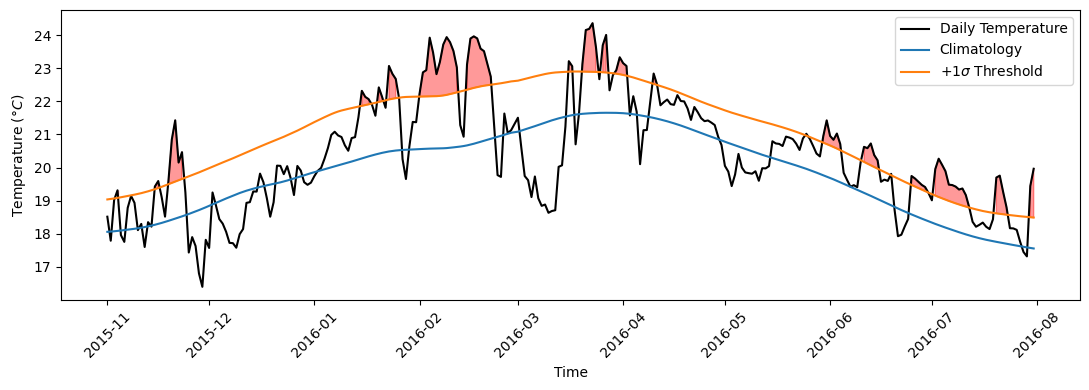

In [219]:
depth_index = 5
start = "2015-11-01"
end = "2016-07-31"

plot_data = result["data"].isel(depth=depth_index).sel(time=slice(start, end))
q90 = select_threshold(plot_data["threshold"], "std", 1)

plt.figure(figsize=(11, 4))
plt.plot(plot_data.time, plot_data.temp, label="Daily Temperature", c='black')
plt.plot(plot_data.time, plot_data.climatology, label="Climatology")
plt.plot(plot_data.time, q90, label="$+1\sigma$ Threshold")
plt.fill_between(
    plot_data.time.values,
    plot_data.temp.values,
    q90.values,
    where=(plot_data.temp.values > q90.values),
    alpha=0.4,
    color='red'
)
plt.xlabel("Time")
plt.ylabel("Temperature ($\degree C$)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Helper Function Demos

For the curious and/or thorough reader, below are demonstrations of the helpers used by the higher level functions in the workflow.

## `noleap_dayofyear()`

Maps dates to a consistent 1,...,365 climatological calendar. Dates after 28 February in leap years are shifted backwards by one day after 29 February has been removed.

In [ ]:
leap_dates = pd.date_range("2016-02-26", "2016-03-03", freq="1D")
leap_dates = leap_dates[~((leap_dates.month == 2) & (leap_dates.day == 29))]
leap_da = xr.DataArray(leap_dates, dims="time", coords={"time": leap_dates})

comparison = pd.DataFrame({
    "date": leap_dates,
    "ordinary_dayofyear": leap_da.time.dt.dayofyear.values,
    "noleap_dayofyear": noleap_dayofyear(leap_da.time).values,
})

comparison

,date,ordinary_dayofyear,noleap_dayofyear
0,2016-02-26,57,57
1,2016-02-27,58,58
2,2016-02-28,59,59
3,2016-03-01,61,60
4,2016-03-02,62,61
5,2016-03-03,63,62


## `_smooth_cyclic()`

Climatological statistics are smoothed across day-of-year using a centred rolling mean that wraps across the end of the year.

This small example uses a 5-day smoother to make the wrap-around easy to see.

In [ ]:
toy = xr.DataArray(
    np.arange(1, 11, dtype=float),
    dims="dayofyear",
    coords={"dayofyear": np.arange(1, 11)},
    name="toy",
)
toy_smoothed = _smooth_cyclic(toy, smooth_window=5)

pd.DataFrame({
    "dayofyear": toy.dayofyear.values,
    "values": toy.values,
    "cyclic_5day_mean": toy_smoothed.values,
})


,dayofyear,values,cyclic_5day_mean
0,1,1.0,5.0
1,2,2.0,4.0
2,3,3.0,3.0
3,4,4.0,4.0
4,5,5.0,5.0
5,6,6.0,6.0
6,7,7.0,7.0
7,8,8.0,8.0
8,9,9.0,7.0
9,10,10.0,6.0


## `apply_dayofyear()`

The climatology is indexed by `dayofyear`, whereas observations are indexed by actual `time`. `apply_dayofyear()` maps each climatological day back onto every matching date in the observed series.

For example, the threshold for climatological day 20 is reused on day 20 of every year.

In [201]:
q90_clim = select_threshold(threshold_climatology, "quantile", 0.90)
q90_time = apply_dayofyear(q90_clim, daily)

print("Original coordinate axes:")
print(q90_clim.coords)
print("\nCoordinates afer mapping to the observation time axis:")
print(q90_time.coords)

Original coordinate axes:
Coordinates:
  * depth      (depth) float32 0.0 6.0 10.0 14.0 16.0 ... 46.0 48.0 50.0 52.0
    lon        float64 151.3
    lat        float64 -33.89
  * dayofyear  (dayofyear) int64 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

Coordinates afer mapping to the observation time axis:
Coordinates:
  * depth      (depth) float32 0.0 6.0 10.0 14.0 16.0 ... 46.0 48.0 50.0 52.0
    lon        float64 ...
    lat        float64 ...
    dayofyear  (time) int64 317 318 319 320 321 322 323 ... 66 67 68 69 70 71 72
  * time       (time) datetime64[ns] 1990-11-13 1990-11-14 ... 2024-03-13



## `fill_gaps()` — 1D example

Short non-exceedance gaps bounded by exceedance days are joined. Here the two-day `False` gap is filled when `max_gap_length=2`.

In [ ]:
gap_example = np.array([
    False, False,
    True, True, True,
    False, False,
    True, True, True, True,
    False,
])
filled_example = fill_gaps(gap_example, max_gap_length=2)

pd.DataFrame({
    "day": np.arange(len(gap_example)),
    "input": gap_example,
    "after_fill_gaps": filled_example,
})

,day,input,after_fill_gaps
0,0,False,False
1,1,False,False
2,2,True,True
3,3,True,True
4,4,True,True
5,5,False,True
6,6,False,True
7,7,True,True
8,8,True,True
9,9,True,True


## `remove_short_runs()` — 1D example

True runs shorter than the required minimum duration are removed. Here a 3-day run disappears while a 6-day run remains.

In [ ]:
run_example = np.array([
    False,
    True, True, True,
    False, False,
    True, True, True, True, True, True,
    False,
])
filtered_example = remove_short_runs(run_example, min_run_length=5)

pd.DataFrame({
    "day": np.arange(len(run_example)),
    "input": run_example,
    "after_remove_short_runs": filtered_example,
})

,day,input,after_remove_short_runs
0,0,False,False
1,1,True,False
2,2,True,False
3,3,True,False
4,4,False,False
5,5,False,False
6,6,True,True
7,7,True,True
8,8,True,True
9,9,True,True


## `check_threshold_nesting()` on raw exceedance masks

Within a threshold family, increasing the threshold should never create more exceedance events than a lower threshold.

For example, if $q_{0.9}(t) > q_{0.8}(t)$, then $T(t)>q_{0.9}(t) \Rightarrow T(t)>q_{0.8}(t).$

The report below checks this separately for `quantile`, `offset`, and `std` thresholds.

In [ ]:
raw_nesting = check_threshold_nesting(exceedance)
raw_nesting

,threshold_method,n_thresholds,min_value,max_value,n_violations,is_nested
0,quantile,2,0.8,0.9,0,True
1,offset,2,1.0,2.0,0,True
2,std,2,1.0,2.0,0,True


### Nesting reports from the complete wrapper

In [ ]:
print("Raw exceedance nesting:")
display(result["raw_nesting"])

print("Event-mask nesting:")
display(result["event_nesting"])

Raw exceedance nesting:


,threshold_method,n_thresholds,min_value,max_value,n_violations,is_nested
0,quantile,2,0.8,0.9,0,True
1,offset,2,1.0,2.0,0,True
2,std,2,1.0,2.0,0,True


Event-mask nesting:


,threshold_method,n_thresholds,min_value,max_value,n_violations,is_nested
0,quantile,2,0.8,0.9,0,True
1,offset,2,1.0,2.0,0,True
2,std,2,1.0,2.0,0,True


The two nesting checks locate different classes of problems:

| Result | Interpretation |
|---|---|
| raw nesting fails | threshold calculation, threshold ordering, or time/depth alignment problem |
| raw passes, event nesting fails | gap-filling or minimum-duration processing problem |
| both pass, final plot/table appears non-monotone | event-catalogue grouping, depth filtering, event matching, or plotting problem |

This is why `run_mhw_detection()` retains the raw exceedance mask, processed event mask, labels, and event table separately.